# Imports + important definitions:

In [1]:
#Imports:

from chime.calibration import load_Learmonth_data
from scipy import interpolate

import numpy as np
import matplotlib.pyplot as plt
import chime
from scipy.optimize import curve_fit
import glob
from tqdm import trange
import os
import datetime



sample_data = "/home/scratch/dbautist/CHIME_archive/2025_160"
chime_data, frequency, timestamps = chime.calibration.load_CHIME_data(sample_data)


df = load_Learmonth_data("/home/scratch/dbautist/CHIME_archive/learmonthData/L251015.SRD")


# Defining the definitions where Jy is more important here

In [2]:
#Looping process to get the median data for that day:

learmonth = "/home/scratch/dbautist/CHIME_archive/learmonthData/"
learmonth_files = glob.glob(f'{learmonth}/L2505*SRD')

def daily_median(path, frequency):  #def in solar flux units
    
    '''Definition for mapping through each day in the wild card
    file path for the month(for example, January of 2026), maps out 
    and calculates the median for each day in that month in units 
    of Solar Flux Units'''

    df = load_Learmonth_data(path)
    med = np.nanmedian(df[frequency])
   
    return med

def daily_median_Jy(path, frequency):  #def in units of Janskys
    
    '''Same thing as the previous function except med is now being
    mulitplied by 10000 to convert SFU into units of Janksys'''

    df = load_Learmonth_data(path)
    med = np.nanmedian(df[frequency]) * 10000
    return med
                 

# defining lists and appending the data 

In [3]:
median_list = []  # defining empty lists 
median_list_Jy = [] #list of medians for each day in units of Janskys 

for i in trange(len(learmonth_files)):     
    output = daily_median(learmonth_files[i], '410')
    output_Jy = daily_median_Jy(learmonth_files[i], '410')
#appending the files:
    median_list.append(output)    
    median_list_Jy.append(output_Jy)

  0%|          | 0/31 [00:00<?, ?it/s]100%|██████████| 31/31 [04:18<00:00,  8.34s/it]


In [4]:
#Organizing by months + seeing trends:

months = ['10']
month_dict = {}

for month in months:
    string = ""
    month_dict[month] = glob.glob(f'{learmonth}/L25{month}*SRD')
      
day_path = month_dict['10'][0]  #for a singular month as of right now

day = glob.glob(f'{learmonth}/L251015*SRD')
print(day)

['/home/scratch/dbautist/CHIME_archive/learmonthData/L251015.SRD']


# Filtering process

In [5]:
#filtering:

def filtering(df):  #Filtering data for NaNs
    median = (not np.isnan(np.nanmedian(df['410']))) and np.nanmedian(df['410']) != 1 and np.nanmedian(df['410']) > 0
    result = median
    return result

#Lists:

good_data = []
bad_data = []
good_date = []
bad_date = []

good_data_Jy = good_data * 10000
bad_data_Jy = bad_data * 10000    

In [6]:
#Looping process:

for month in months:
    for i in trange(len(month_dict[month])):
        path = month_dict[month][i]
        df = load_Learmonth_data(path)
        
        if filtering(df):
            good_data.append(path)
        else:
            bad_data.append(path)
                
for date in good_data:
    base = os.path.basename(date)[5:7]
    num_date = int(base)
    good_date.append(num_date)
    
for nodate in bad_data:
    nobase = os.path.basename(nodate)[5:7]
    no_num_date = int(nobase)
    bad_date.append(no_num_date)

100%|██████████| 31/31 [02:34<00:00,  4.97s/it]


# Only applying the good data to y

In [7]:
flux_410 = []  #flux_410 = data that is good 

for i in trange(len(good_data)):
    p = good_data[i]
    df = load_Learmonth_data(p) 
    flux_410.append(np.nanmedian(df['410']))
    
print(flux_410)

flux_Jy = [x * 10000 for x in flux_410] #flux_Jy = flux_410 just in units of Janskys

100%|██████████| 17/17 [01:24<00:00,  4.95s/it]

[55.0, 54.0, 49.0, 46.0, 45.0, 40.0, 39.0, 38.0, 39.0, 39.0, 39.0, 41.0, 43.0, 39.0, 38.0, 39.0, 39.0]


# The plot including Estimated bad data:

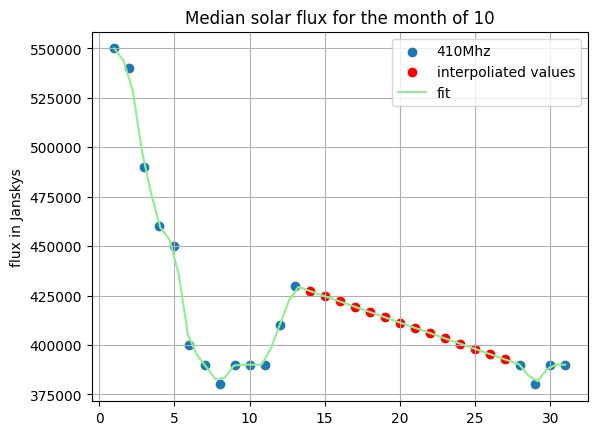

In [9]:
#plot in units of Janskys:
f = interpolate.interp1d((good_date), (flux_Jy))
xnew = good_date
ynew = f(good_date)
yfilled = f(bad_date)

plt.figure()
plt.scatter(good_date, flux_Jy, label='410Mhz')
plt.scatter(bad_date, yfilled, color='red', label='interpoliated values')
m = np.linspace(1, 31)
plt.plot(m, f(m), color='lightgreen', label='fit')


plt.legend()
plt.title(f"Median solar flux for the month of {month}")
plt.ylabel("flux in Janskys")

plt.grid()
#plt.hlines(np.median(flux_410), min(good_data), max(good_data))
plt.legend()
